In [2]:
import torch

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

In [3]:

from PIL import Image
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results

model = build_sam3_image_model()
processor = Sam3Processor(model)

E:\Uni\Bachelorarbeit\sam3\sam3\model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [4]:
image_path = "dataset/mvtec_anomaly_detection/carpet/test/thread/000.png"

ground_truth = "dataset/mvtec_anomaly_detection/carpet/ground_truth/thread/000_mask.png"

found 1 object(s)


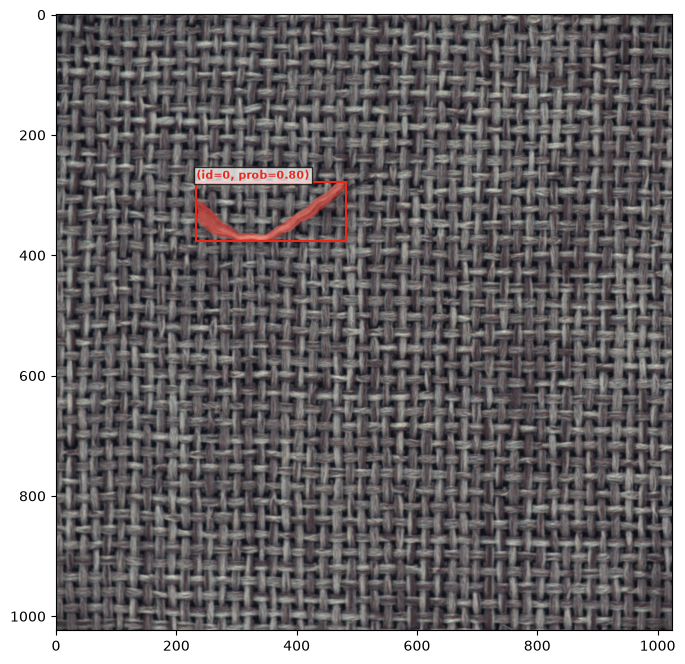

In [5]:
image = Image.open(image_path).convert("RGB")
inference_state = processor.set_image(image)

processor.reset_all_prompts(inference_state)

inference_state = processor.set_confidence_threshold(state=inference_state, threshold=0.25)
inference_state = processor.set_text_prompt(state=inference_state, prompt="loose thread")


masks, boxes, scores = inference_state["masks"], inference_state["boxes"], inference_state["scores"]
img0 = Image.open(image_path)
plot_results(image, inference_state)


tensor(0.8047, device='cuda:0', dtype=torch.bfloat16)


C:\Users\falzb\AppData\Local\Temp\ipykernel_8952\1525701558.py:82: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


'\nimage_auroc.update(item)\npixel_auroc.update(item)\npixel_aupro.update(item)\n\nprint("image AUROC: ")\nprint(image_auroc.compute())\nprint("pixel AUROC: ")\nprint(pixel_auroc.compute())\nprint("pixel AUPRO")\n# '

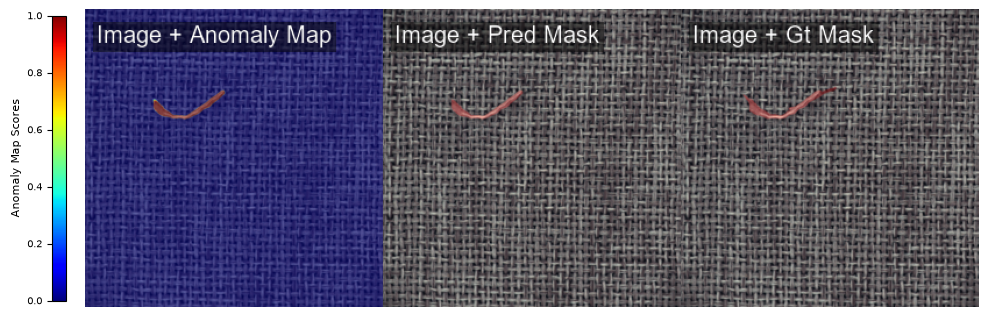

In [6]:
from anomalib.metrics import AUROC, AUPRO, PRO
from anomalib.data.dataclasses.torch import ImageBatch, ImageItem
from torchvision import transforms
from anomalib.visualization.image.item_visualizer import visualize_image_item
from anomalib.visualization import visualize_anomaly_map
import numpy as np
import matplotlib.pyplot as plt
image_auroc = AUROC(fields=["pred_score", "gt_label"], prefix="image")
pixel_auroc = AUROC(fields=["anomaly_map", "gt_mask"], prefix="pixel")
pixel_aupro = AUPRO(fpr_limit=0.3,fields=["anomaly_map", "gt_mask"])
gt = Image.open(ground_truth)

transform = transforms.ToTensor()

pred_label= torch.tensor(0, dtype=int).to(device="cuda")

if(masks.size(dim=0) != 0):
    single_map = torch.max(inference_state["masks_logits"], dim=0).values
    single_mask = torch.max(masks, dim=0).values
    pred_label = torch.tensor(1, dtype=int).to(device="cuda")
    scores = torch.max(scores, dim=0).values
else:
    single_map = torch.zeros(1,inference_state["original_height"], inference_state["original_width"]).to(device="cuda")
    single_mask = torch.zeros(1,inference_state["original_height"], inference_state["original_width"], dtype=int).to(device="cuda")
    scores = torch.zeros(1).to(device="cuda")

print(scores)


item = ImageItem(
    image=transform(image).to(device="cuda"),
    gt_label=torch.tensor(1, dtype=int).to(device="cuda"),
    image_path=image_path,
    pred_label=pred_label,
    pred_mask=single_mask,
    pred_score=scores,
    gt_mask=transform(gt).to(device="cuda"),
    mask_path="",
    anomaly_map = single_map
)



vis_result = visualize_image_item(item, overlay_fields=[("image", ["anomaly_map"]),
                                                        ("image", ["pred_mask"]),
                                                        ("image", ["gt_mask"])],
                                    overlay_fields_config={
                                        "anomaly_map": {"colormap": True, "normalize": True},
                                        "pred_mask": {"mode": "fill", "color": (255, 0, 0), "alpha": 0.5},
                                        "gt_mask": {"mode": "fill", "color": (255, 0, 0), "alpha": 0.5}},
                                    text_config={
                                        "font": "arial.ttf",
                                        "size": 20
                                    }
                                )

fig, ax = plt.subplots(figsize=(10, 6))

ax.imshow(np.asarray(vis_result))
ax.axis("off")

cmap = plt.cm.jet
norm = plt.Normalize(vmin=0, vmax=1)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    location="left",
    fraction=0.025,
    pad=0.02,
    shrink=0.5,
    aspect=20,
)

cbar.set_label("Anomaly Map Scores", fontsize=8)
cbar.ax.tick_params(labelsize=7)

fig.tight_layout()
fig.show()
fig.savefig("visualizations/carpet_thread_loose_thread.png", bbox_inches="tight")
#vis_result.save(f"visualizations/metal_nut_flip_flipped_nut.png")
#del vis_result
'''
image_auroc.update(item)
pixel_auroc.update(item)
pixel_aupro.update(item)

print("image AUROC: ")
print(image_auroc.compute())
print("pixel AUROC: ")
print(pixel_auroc.compute())
print("pixel AUPRO")
# '''